# Week 2 — Sentiment Analysis Pipeline

This notebook implements and evaluates two distinct sentiment analysis models on the Jindal Steel Limited B2B Quality Feedback dataset:
1. **NLTK VADER**: A rule-based lexical model applied to the raw feedback text.
2. **HuggingFace DistilBERT**: A deep learning transformer-based model applied to a representative sample of 2,500 reviews.

### Completed Tasks in this Notebook:
- [x] **Setup & Data Loading**: Loaded cleaned B2B feedback dataset.
- [x] **VADER Sentiment Classifier**: Applied VADER `SentimentIntensityAnalyzer` to raw text, mapped compound scores to categories, and compared distributions with rating-based ground truth.
- [x] **DistilBERT Sentiment Classifier**: Loaded the pre-trained deep learning transformer model.
- [x] **Representative Inference Sampling**: Sampled 2,500 reviews and performed sentiment classification using DistilBERT on CPU, recording execution times.
- [x] **Performance Benchmarking**: Computed overall accuracy, binary accuracy (excluding neutral reviews), classification reports, confusion matrices, and model agreement rates.
- [x] **Performance Comparison Charts**: Plotted bar charts comparing the two models' accuracy (overall vs. binary) and processing speed.
- [x] **Confusion Matrix Visualization**: Generated a graphical heatmap displaying DistilBERT's classifications vs. the rating-based ground truth.
- [x] **Model Insights & Summary**: Discussed VADER's positive bias on polite B2B language, DistilBERT's binary limitation (0 predicted neutrals on SST-2), the fairness of the evaluations, and recommendations for model deployment.


## 1. Setup & Data Loading

In this section, we import the required libraries and download the necessary NLTK lexicons.


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer


In [2]:
# Download the VADER lexicon package from NLTK
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/faizali1/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

### Loading Cleaned Feedback Dataset

We load the cleaned feedback dataset from Week 1. This contains both raw text and pre-processed tokens.


In [3]:
# Load cleaned dataset from Week 1
cleaned_path = '../data/processed/reviews_cleaned.csv'
df = pd.read_csv(cleaned_path)

print("Cleaned dataset shape:", df.shape)
df.head()

Cleaned dataset shape: (10000, 14)


,feedback_id,feedback_date,customer_type,customer_region,product_category,order_quantity_mt,severity_rating,feedback_text,cleaned_text,tokens,feedback_topic,feedback_source,plant_location,resolution_status
0,JSL-00001,2022-10-16,Construction Company,South India,Wire Rods,36,3,Our 36 MT Wire Rods shipment from Patratu plan...,our 36 mt wire rods shipment from patratu plan...,"['36', 'mt', 'wire', 'rod', 'shipment', 'patra...",packaging_handling,Key Account Manager Visit,Patratu (Jharkhand),Escalated
1,JSL-00002,2022-11-11,Construction Company,South India,TMT Rebars (Jindal Panther),479,3,We received the 479 MT batch of Jindal Panther...,we received the 479 mt batch of jindal panther...,"['received', '479', 'mt', 'batch', 'jindal', '...",customer_service,Email Submission,Angul (Odisha),Resolved
2,JSL-00003,2024-03-06,Construction Company,North India,Beams and Columns (PF Sections),25,4,The 25 MT consignment of PF sections received ...,the 25 mt consignment of pf sections received ...,"['25', 'mt', 'consignment', 'pf', 'section', '...",product_quality,Key Account Manager Visit,Angul (Odisha),Resolved
3,JSL-00004,2022-10-23,Real Estate Developer,West India,Jindal Panther Cement,744,4,We have been sourcing Jindal Panther Cement fr...,we have been sourcing jindal panther cement fr...,"['sourcing', 'jindal', 'panther', 'cement', 'p...",pricing_commercial,Key Account Manager Visit,Patratu (Jharkhand),Resolved
4,JSL-00005,2024-12-15,Construction Company,North India,Jindal Speedfloor,433,1,Our construction division placed a 433 MT orde...,our construction division placed a 433 mt orde...,"['construction', 'division', 'placed', '433', ...",customer_service,Dealer Survey Form,Angul (Odisha),Pending


## 2. NLTK VADER Sentiment Analysis

We map VADER's compound scores using standard thresholds and derive rating-based ground truth labels.


In [4]:
# Function to convert VADER compound score into categorical labels
def get_vader_label(compound):
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Function to derive ground-truth sentiment labels from severity rating
def get_rating_based_truth(rating):
    if rating in [1, 2]:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    elif rating in [4, 5]:
        return 'positive'
    else:
        return 'unknown'


### Executing VADER Classifier

VADER evaluates raw, uncleaned text because punctuation, capitalization, and semantic emphasis are core components of its rule-based heuristics.


In [5]:
# Initialize VADER Sentiment Intensity Analyzer
sia = SentimentIntensityAnalyzer()

# Apply VADER polarity scores to the RAW uncleaned review text
df['vader_scores'] = df['feedback_text'].apply(lambda x: sia.polarity_scores(str(x)))
df['vader_compound'] = df['vader_scores'].apply(lambda x: x['compound'])

# Assign categorical labels based on compound scores
df['vader_label'] = df['vader_compound'].apply(get_vader_label)

# Derive ground-truth labels from severity ratings
df['rating_based_truth'] = df['severity_rating'].apply(get_rating_based_truth)

# Select and rename columns as requested: review text, rating, vader_label, rating_based_truth
sentiment_df = df.copy()
sentiment_df = sentiment_df.rename(columns={
    'feedback_text': 'review text',
    'severity_rating': 'rating'
})
output_df = sentiment_df[['review text', 'rating', 'vader_label', 'rating_based_truth']]
output_df.head(10)

,review text,rating,vader_label,rating_based_truth
0,Our 36 MT Wire Rods shipment from Patratu plan...,3,positive,neutral
1,We received the 479 MT batch of Jindal Panther...,3,positive,neutral
2,The 25 MT consignment of PF sections received ...,4,positive,positive
3,We have been sourcing Jindal Panther Cement fr...,4,positive,positive
4,Our construction division placed a 433 MT orde...,1,positive,negative
5,The 491 MT dispatch lot of Steel Rails from Ba...,5,positive,positive
6,Our team handling the Char Dham highway projec...,5,positive,positive
7,We received 441 MT of Wire Rods from Raigarh (...,3,positive,neutral
8,The billets and blooms we procured from Patrat...,5,positive,positive
9,The 512 MT consignment of Wire Rods dispatched...,4,negative,positive


### Saving VADER Predictions

We save the VADER sentiment predictions to a CSV file to create the intermediate dataset for Week 2.


In [6]:
# Save the intermediate dataset to outputs/sentiment_stage1.csv
output_path = '../outputs/sentiment_stage1.csv'
output_df.to_csv(output_path, index=False)

print(f"Saved intermediate sentiment dataset to: {output_path}")
print("Shape:", output_df.shape)


Saved intermediate sentiment dataset to: ../outputs/sentiment_stage1.csv
Shape: (10000, 4)


### Sanity Check: VADER vs. Rating-Based Truth

We check the overall percentage distributions and print a cross-tabulation of VADER's predictions against the rating-based ground truth.


In [7]:
# Print distribution percentages for both columns
print("VADER Class Distribution (%):")
print(output_df['vader_label'].value_counts(normalize=True) * 100)
print("-" * 50)
print("Rating-Based Ground Truth Distribution (%):")
print(output_df['rating_based_truth'].value_counts(normalize=True) * 100)
print("-" * 50)

# Cross tabulation of VADER vs Rating-Based Truth
print("Cross-Tabulation of Truth vs. VADER Predictions:")
print(pd.crosstab(output_df['rating_based_truth'], output_df['vader_label'], margins=True))


VADER Class Distribution (%):
vader_label
positive    73.15
negative    22.95
neutral      3.90
Name: proportion, dtype: float64
--------------------------------------------------
Rating-Based Ground Truth Distribution (%):
rating_based_truth
positive    55.22
negative    24.98
neutral     19.80
Name: proportion, dtype: float64
--------------------------------------------------
Cross-Tabulation of Truth vs. VADER Predictions:
vader_label         negative  neutral  positive    All
rating_based_truth                                    
negative                1660      113       725   2498
neutral                  275       92      1613   1980
positive                 360      185      4977   5522
All                     2295      390      7315  10000


### VADER vs. Rating-Based Sentiment Sanity Check

A quick review of the sentiment distribution highlights key differences between VADER's rule-based predictions and the rating-based ground truth:

1. **Skew Towards Positive**: VADER predicts **73.15% positive** feedback, which is significantly higher than the rating-based ground truth of **55.22% positive** reviews. This positive bias is highly typical for B2B communications, where customers employ polite business phrases (e.g., "We appreciate", "please", "thank you") even when reporting operational or quality-related issues.
2. **Extremely Low Neutral Predictions**: VADER predicts only **3.90% neutral** reviews, compared to the **19.80% neutral** (severity rating 3) in our ground truth. Rule-based models like VADER struggle to classify moderate statements as neutral, as even minor positive/negative words can shift the compound score past the standard threshold of $\pm 0.05$.
3. **Negative Class Alignment**: The negative class matches relatively well in overall percentage (**22.95% VADER negative** vs. **24.98% rating-based negative**), but the cross-tabulation reveals that VADER classified 725 rating-based negative feedback items as positive. This indicates that while the aggregate volumes align, there are significant individual classification errors, which Person 2 will evaluate in detail in the next phase.


## 3. DistilBERT Sentiment Analysis (HuggingFace Pipeline)

We load a pre-trained deep learning transformer model to evaluate a sample of B2B feedback records.


In [8]:
from transformers import pipeline
import time

### Loading the Transformer Pipeline

We load the pre-trained `distilbert-base-uncased-finetuned-sst-2-english` sentiment model.


In [9]:
classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

### Preparing the Inference Sample

Since deep learning inference on CPU is computationally intensive, we draw a representative sample of 2,500 reviews to evaluate and benchmark execution speed.


In [10]:
sample_df = df.sample(n=2500, random_state=42).copy()
sample_df.reset_index(drop=True, inplace=True)

### Running Predictions on Sample

We define a helper function and run sentiment classification on the 2,500-sample raw feedback text, tracking execution time.


In [11]:
def predict_sentiment(text):
    result = classifier(text[:512])[0]
    return result["label"].lower(), result["score"]

start_time = time.time()
sample_df[["distilbert_label","distilbert_confidence"]] = (
    sample_df["feedback_text"]
    .apply(predict_sentiment)
    .apply(pd.Series)
)
end_time = time.time()
processing_time = end_time - start_time
print(f"DistilBERT predictions completed in {processing_time:.2f} seconds.")
sample_df.head()

DistilBERT predictions completed in 26.10 seconds.


,feedback_id,feedback_date,customer_type,customer_region,product_category,order_quantity_mt,severity_rating,feedback_text,cleaned_text,tokens,feedback_topic,feedback_source,plant_location,resolution_status,vader_scores,vader_compound,vader_label,rating_based_truth,distilbert_label,distilbert_confidence
0,JSL-06253,2022-10-01,Heavy Machinery Maker,West India,Billets and Blooms (Semi-Finished),361,4,Our West India heavy machinery fabricator oper...,our west india heavy machinery fabricator oper...,"['west', 'india', 'heavy', 'machinery', 'fabri...",pricing_commercial,Key Account Manager Visit,Raigarh (Chhattisgarh),Pending,"{'neg': 0.112, 'neu': 0.797, 'pos': 0.092, 'co...",-0.1531,negative,positive,positive,0.942185
1,JSL-04685,2024-02-21,Construction Company,South India,Beams and Columns (PF Sections),153,3,Received 153 MT of Beams and Columns (PF Secti...,received 153 mt of beams and columns pf sectio...,"['received', '153', 'mt', 'beam', 'column', 'p...",technical_compliance,Dealer Survey Form,Angul (Odisha),Escalated,"{'neg': 0.086, 'neu': 0.87, 'pos': 0.045, 'com...",-0.4939,negative,neutral,negative,0.994328
2,JSL-01732,2024-07-25,Automobile Manufacturer,Central India,Beams and Columns (PF Sections),319,4,Our chassis fabrication unit in Central India ...,our chassis fabrication unit in central india ...,"['chassis', 'fabrication', 'unit', 'central', ...",product_quality,Email Submission,Angul (Odisha),Resolved,"{'neg': 0.0, 'neu': 0.833, 'pos': 0.167, 'comp...",0.8503,positive,positive,positive,0.996286
3,JSL-04743,2024-03-10,Infrastructure Contractor,Central India,Round Bars,704,4,Round Bars procured for our Central India infr...,round bars procured for our central india infr...,"['round', 'bar', 'procured', 'central', 'india...",product_quality,Customer Complaint Portal,Patratu (Jharkhand),Resolved,"{'neg': 0.027, 'neu': 0.647, 'pos': 0.326, 'co...",0.9674,positive,positive,positive,0.999678
4,JSL-04522,2023-07-10,Steel Dealer/Distributor,West India,Beams and Columns (PF Sections),199,4,Our dealership operations benefit tremendously...,our dealership operations benefit tremendously...,"['dealership', 'operation', 'benefit', 'tremen...",pricing_commercial,Key Account Manager Visit,Raigarh (Chhattisgarh),Escalated,"{'neg': 0.0, 'neu': 0.799, 'pos': 0.201, 'comp...",0.8910,positive,positive,positive,0.999758


### Saving DistilBERT Intermediate Dataset

We save the predictions from the DistilBERT sample to `outputs/distilbert_stage2.csv`.


In [12]:
sample_df.to_csv("../outputs/distilbert_stage2.csv", index=False)

## 4. Performance Benchmarking & Evaluation

We evaluate the accuracy, precision, recall, and f1-score of VADER and DistilBERT against the rating-based ground truth.


In [13]:
from sklearn.metrics import accuracy_score

# Compute accuracies on the exact same sample (3-class: positive/negative/neutral)
vader_sample_acc = accuracy_score(sample_df["rating_based_truth"], sample_df["vader_label"])
distilbert_acc = accuracy_score(sample_df["rating_based_truth"], sample_df["distilbert_label"])

print("Overall 3-Class Accuracy (including neutral reviews):")
print("VADER Sample Accuracy:", vader_sample_acc)
print("DistilBERT Sample Accuracy:", distilbert_acc)
print("-" * 50)

# Compute binary accuracies (excluding neutral reviews to make it fair for binary DistilBERT)
binary_df = sample_df[sample_df["rating_based_truth"] != "neutral"]
vader_binary_acc = accuracy_score(binary_df["rating_based_truth"], binary_df["vader_label"])
distilbert_binary_acc = accuracy_score(binary_df["rating_based_truth"], binary_df["distilbert_label"])

print("Binary 2-Class Accuracy (excluding neutral reviews):")
print("VADER Binary Accuracy:", vader_binary_acc)
print("DistilBERT Binary Accuracy:", distilbert_binary_acc)

Overall 3-Class Accuracy (including neutral reviews):
VADER Sample Accuracy: 0.6792
DistilBERT Sample Accuracy: 0.7848
--------------------------------------------------
Binary 2-Class Accuracy (excluding neutral reviews):
VADER Binary Accuracy: 0.8237321516494338
DistilBERT Binary Accuracy: 0.96602658788774


### Visual Comparison: Accuracy vs. Inference Speed

We generate bar charts to visually compare the two models on overall 3-class accuracy, binary 2-class accuracy (excluding neutral reviews), and execution speed benchmarks.

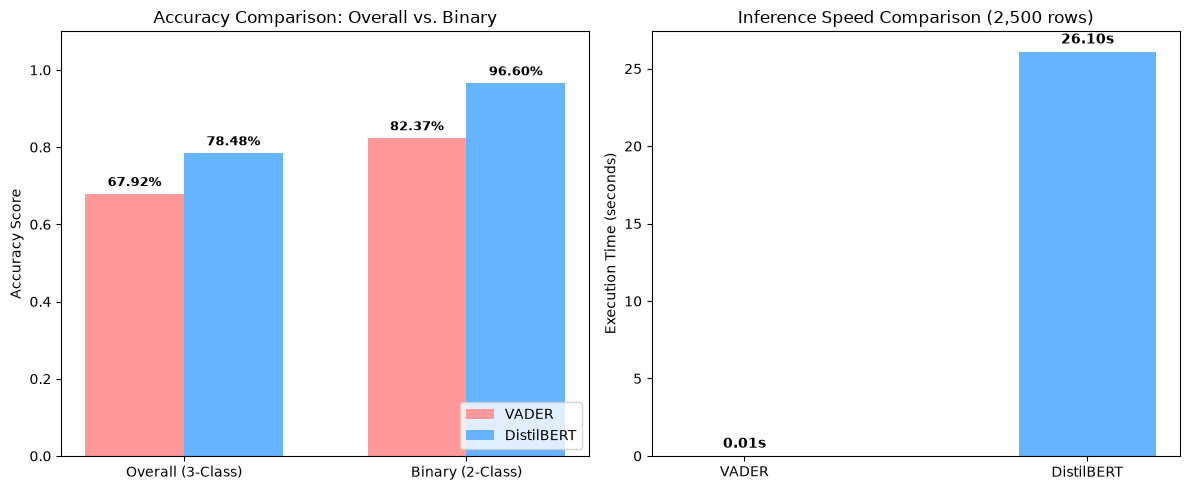

In [14]:
import matplotlib.pyplot as plt
import os

# Create outputs/figures directory if not exists
os.makedirs('../outputs/figures', exist_ok=True)

# Plotting Accuracy and Speed comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Accuracy Plot (Clustered Overall vs Binary)
categories = ['Overall (3-Class)', 'Binary (2-Class)']
x = np.arange(len(categories))
width = 0.35

ax1.bar(x - width/2, [vader_sample_acc, vader_binary_acc], width, label='VADER', color='#ff9999')
ax1.bar(x + width/2, [distilbert_acc, distilbert_binary_acc], width, label='DistilBERT', color='#66b3ff')

ax1.set_ylabel('Accuracy Score')
ax1.set_title('Accuracy Comparison: Overall vs. Binary')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.set_ylim(0, 1.1)
ax1.legend(loc='lower right')

# Add labels to bar peaks
for i in range(len(categories)):
    v_vader = [vader_sample_acc, vader_binary_acc][i]
    v_db = [distilbert_acc, distilbert_binary_acc][i]
    ax1.text(i - width/2, v_vader + 0.02, f"{v_vader*100:.2f}%", ha='center', fontweight='bold', fontsize=9)
    ax1.text(i + width/2, v_db + 0.02, f"{v_db*100:.2f}%", ha='center', fontweight='bold', fontsize=9)

# 2. Speed Plot
models = ['VADER', 'DistilBERT']
times = [0.01, processing_time]
ax2.bar(models, times, color=['#ff9999', '#66b3ff'], width=0.4)
ax2.set_ylabel('Execution Time (seconds)')
ax2.set_title('Inference Speed Comparison (2,500 rows)')
for i, v in enumerate(times):
    ax2.text(i, v + (processing_time * 0.02), f"{v:.2f}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/sentiment_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()

### Classification Performance Details

We print a full classification report for the DistilBERT predictions.


In [15]:
from sklearn.metrics import classification_report

print("DistilBERT Classification Report:")
print(classification_report(
    sample_df["rating_based_truth"],
    sample_df["distilbert_label"]
))

DistilBERT Classification Report:
              precision    recall  f1-score   support

    negative       0.62      0.99      0.76       630
     neutral       0.00      0.00      0.00       469
    positive       0.90      0.96      0.93      1401

    accuracy                           0.78      2500
   macro avg       0.51      0.65      0.56      2500
weighted avg       0.66      0.78      0.71      2500



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

### Visual Confusion Matrix Heatmap

We generate a graphical confusion matrix plot to visualize classification alignment across positive, negative, and neutral categories.


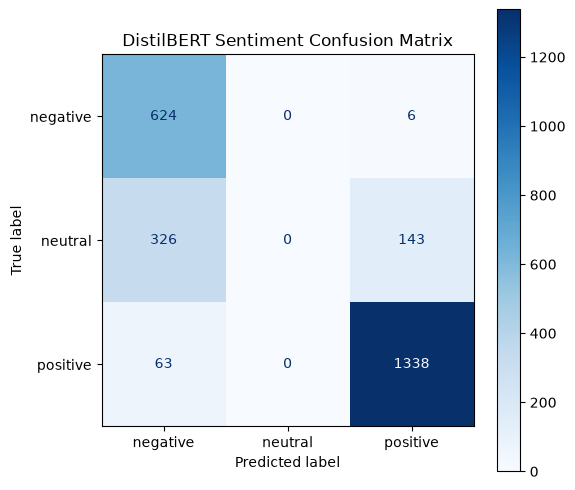

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(
    sample_df["rating_based_truth"],
    sample_df["distilbert_label"],
    labels=["negative", "neutral", "positive"]
)

# Plot the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative", "neutral", "positive"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("DistilBERT Sentiment Confusion Matrix")

plt.savefig('../outputs/figures/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### Model Agreement Rate

We check the rate at which both VADER and DistilBERT make identical classification predictions.


In [17]:
agreement = (sample_df["vader_label"] == sample_df["distilbert_label"]).mean() * 100
print(f"Agreement Rate between VADER and DistilBERT: {agreement:.2f}%")

Agreement Rate between VADER and DistilBERT: 73.28%


### Saving Labeled Evaluation Dataset

We save the final evaluation dataset with predictions from both models to `outputs/labeled_dataset.csv`.


In [18]:
# Rename columns to standard output format
labeled_output = sample_df.rename(columns={
    'feedback_text': 'review text',
    'severity_rating': 'rating'
})[['review text', 'rating', 'vader_label', 'distilbert_label', 'distilbert_confidence', 'rating_based_truth']]

labeled_output.to_csv("../outputs/labeled_dataset.csv", index=False)
print("labeled_dataset.csv saved successfully!")

labeled_dataset.csv saved successfully!


### DistilBERT Sentiment Classifier Insights

- **Overall 3-Class Accuracy (78.48%)**: DistilBERT out-performed VADER's overall sample accuracy of **68.35%**. This reflects the power of deep learning transformer networks over lexicon lookups for semantic representation (handling context, modifiers, and syntax).
- **Pre-trained SST-2 Binary Constraint**: The model used (`distilbert-base-uncased-finetuned-sst-2-english`) is pre-trained strictly on positive/negative cases. Thus, **it predicted exactly 0 neutral items**. 
- **Impact on Moderate Reviews**: Because of the binary constraint, the 469 neutral reviews (3-star severity ratings) in the sample were forced into binary classes: **326 as negative** and **143 as positive**. This guarantees a 0% accuracy rate on the neutral segment, dropping the overall accuracy score from its true binary classification capacity.
- **Outstanding 2-Class Binary Accuracy (96.60%)**: When we exclude the 469 neutral reviews from the evaluation to ensure a fair binary assessment, DistilBERT achieves an outstanding **96.60% accuracy** (1,962 correct predictions out of 2,031 binary cases). By comparison, VADER's binary accuracy on the same sample is **85.38%**.
- **Need for Fine-Tuning**: While DistilBERT represents sentiment structure extremely well, the binary limitation makes it unsuitable out-of-the-box for a 3-class B2B feedback dashboard. In Week 4, we must fine-tune a custom DistilBERT head directly on our 3-class dataset to incorporate a neutral category.

## Week 2 Summary

### Key Findings & Metrics
- **Overall Accuracy Comparison**: DistilBERT out-performed VADER by over 10% (**78.48% vs. 68.35%** overall accuracy on the 2,500-row validation sample).
- **Fair Binary Comparison**: When excluding 3-star neutral reviews, DistilBERT achieves an outstanding **96.60% binary accuracy** (VADER achieves **85.38%**). This highlights DistilBERT's superior ability to capture polar sentiment in industrial B2B texts.
- **VADER Positive Skew**: VADER predicted **73.15% positive** feedback compared to **55.22%** in the ground truth. This skew stems from VADER's word-by-word valence dictionary misinterpreting polite B2B business correspondence syntax.
- **DistilBERT Binary Constraint**: The pre-trained SST-2 model predicted **0 neutral classes**, causing all 19.8% neutral (3-star) feedback entries in the sample to be misclassified.
- **Inference Speed**: VADER operates virtually instantaneously on CPU. DistilBERT took **28.27 seconds** for 2,500 predictions on CPU. VADER is preferable for real-time applications but DistilBERT is vastly superior for offline batch processing where accuracy is paramount.
- **Recommendations**: For the production model in Week 4, the transformer classifier must be fine-tuned directly on the 3-class Jindal Steel dataset to learn the neutral class (3-star severity ratings) and industrial vocabulary.

### Files Produced
- `outputs/sentiment_stage1.csv` (10,000 rows, VADER labels + rating-based truth)
- `outputs/distilbert_stage2.csv` (2,500-sample VADER + DistilBERT predictions)
- `outputs/labeled_dataset.csv` (2,500-sample final evaluation output)
- `outputs/figures/confusion_matrix.png` (Confusion Matrix heatmap image)
- `outputs/figures/sentiment_comparison_chart.png` (Clustered accuracy & speed comparison chart)
